# Week 2 — Poisson noise & SNR in STEM imaging

**Course:** Data Science for Electron Microscopy  
**Week 2 topic:** What is learning? EM data & where noise comes from  
**Notebook scope:** Simulate dose-dependent Poisson noise on a clean synthetic STEM-like image, measure SNR vs dose, and find the dose threshold at which features become invisible.

---

**Learning objectives:** After completing this notebook you can:
1. Explain why electron counts follow Poisson statistics.
2. Simulate Poisson noise on a synthetic image using `np.random.poisson`.
3. Measure signal-to-noise ratio (SNR) for a range of dose levels.
4. Confirm the $\mathrm{SNR} = \sqrt{\lambda}$ law empirically.
5. Identify the dose threshold at which a chosen feature is no longer visually resolvable.

**Estimated time:** 60–90 minutes.  
**Prerequisites:** Week 1 notebook (NumPy arrays, slicing, matplotlib).  
**Runtime:** Colab-compatible; no GPU needed; runs top-to-bottom without manual intervention.

In [1]:
# ── Cell 1: install / imports ────────────────────────────────────────────────
# NumPy, matplotlib, and scipy are pre-installed on Colab.
# Uncomment the line below only if running in a bare environment.
# !pip install --quiet numpy matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter

# Reproducibility
rng = np.random.default_rng(seed=42)

print(f"NumPy version : {np.__version__}")
print("Imports successful.")

NumPy version : 1.26.4
Imports successful.


---

## Part 1 — Why Poisson?

In a STEM experiment, a focused electron probe scans across the sample in a raster pattern. At each probe position (pixel) the electrons that scatter at high angles are collected by the HAADF annular detector. The detector *counts* the arriving electrons.

**The physics:**
- Each electron arrives independently (quantum-mechanical processes are independent).
- The average number of electrons arriving in a fixed dwell time is $\lambda$ (proportional to the local scattering cross-section and the beam current).
- The actual count $N$ in any one pixel fluctuates around $\lambda$ according to the **Poisson distribution**:

$$P(N = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \ldots$$

**Key properties of Poisson:**
- Mean: $\mathbb{E}[N] = \lambda$
- Variance: $\mathrm{Var}(N) = \lambda$
- Standard deviation: $\sigma = \sqrt{\lambda}$
- SNR: $\mathrm{SNR} = \lambda / \sigma = \sqrt{\lambda}$

This means **doubling the dose ($\lambda$) only improves SNR by a factor of $\sqrt{2} \approx 1.41$, not 2.** To double SNR you must quadruple the dose.

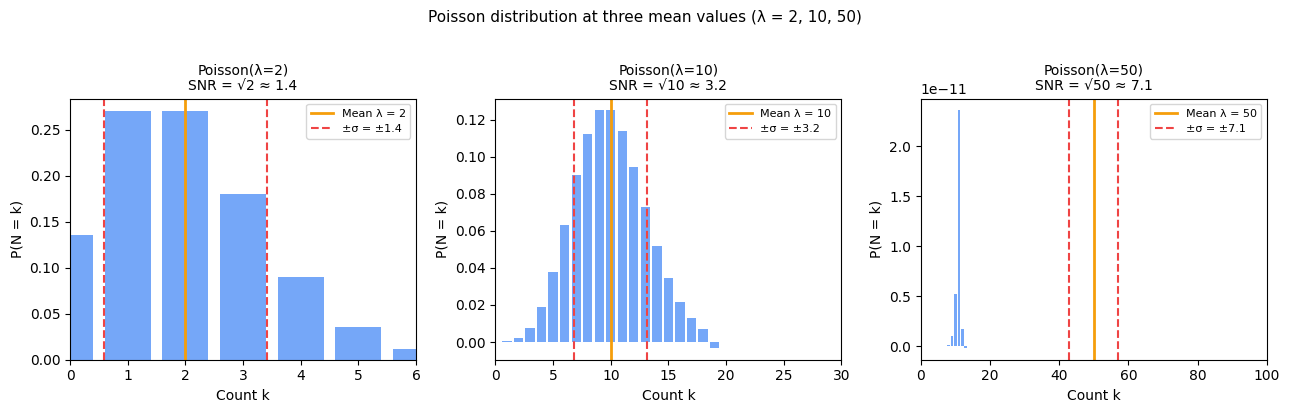

Note: as λ grows, the distribution becomes more symmetric (approaching Gaussian).
But variance = mean still holds — unlike Gaussian where variance is independent of mean.


In [2]:
# ── Cell 2: Poisson distribution at different mean values ───────────────────
# Visualise the Poisson distribution for three λ values to build intuition.

lambdas = [2, 10, 50]   # average counts per pixel
k_max   = 100
k_vals  = np.arange(0, k_max + 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, lam in zip(axes, lambdas):
    # Exact Poisson PMF via recurrence (avoids overflow for large k)
    from math import exp, factorial
    pmf = np.array([lam**k * exp(-lam) / factorial(k) for k in k_vals])
    snr = np.sqrt(lam)

    ax.bar(k_vals[:k_max], pmf[:k_max], color='#3b82f6', alpha=0.7, width=0.8)
    ax.axvline(lam, color='#f59e0b', lw=2, label=f'Mean λ = {lam}')
    ax.axvline(lam - np.sqrt(lam), color='#ef4444', lw=1.5, ls='--', label=f'±σ = ±{snr:.1f}')
    ax.axvline(lam + np.sqrt(lam), color='#ef4444', lw=1.5, ls='--')
    ax.set_title(f'Poisson(λ={lam})\nSNR = √{lam} ≈ {snr:.1f}', fontsize=10)
    ax.set_xlabel('Count k')
    ax.set_ylabel('P(N = k)')
    ax.set_xlim(0, min(k_max, lam*3))
    ax.legend(fontsize=8)

plt.suptitle('Poisson distribution at three mean values (λ = 2, 10, 50)', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()
print("Note: as λ grows, the distribution becomes more symmetric (approaching Gaussian).")
print("But variance = mean still holds — unlike Gaussian where variance is independent of mean.")

---

## Part 2 — Build a clean phantom image

We create a synthetic STEM-like "phantom" — a clean noiseless image representing the true scattering potential. In a real experiment this is what we would measure with infinite dose.  
The phantom contains a regular lattice of atomic columns (bright spots) on a dark background, like a perfect crystal viewed along a zone axis.

Phantom shape : (256, 256)
Phantom min   : 0.074
Phantom max   : 1.000
Number of atomic columns: 256


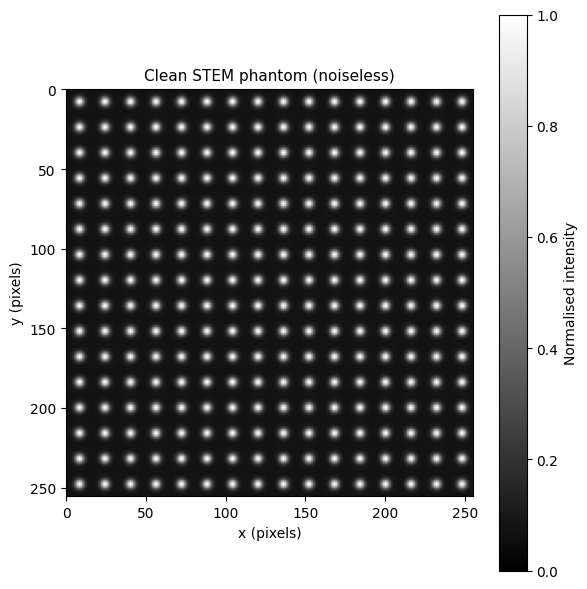

In [3]:
# ── Cell 3: build the clean STEM phantom ────────────────────────────────────

N = 256          # image size in pixels
spacing = 16     # pixel spacing between atomic columns (simulates lattice)
col_radius = 2   # half-width of each column (pixels)

# --- Clean phantom: unit-height Gaussian blobs on a regular lattice
x = np.arange(N)
X, Y = np.meshgrid(x, x)

phantom = np.zeros((N, N), dtype=float)
col_positions = []
for ry in range(spacing // 2, N, spacing):
    for rx in range(spacing // 2, N, spacing):
        # Gaussian blob centred at (rx, ry)
        phantom += np.exp(-((X - rx)**2 + (Y - ry)**2) / (2 * col_radius**2))
        col_positions.append((rx, ry))

# Add a weak background (typical in HAADF: Z-contrast background)
phantom = phantom + 0.08

# Normalise to [0, 1]
phantom = phantom / phantom.max()

print(f"Phantom shape : {phantom.shape}")
print(f"Phantom min   : {phantom.min():.3f}")
print(f"Phantom max   : {phantom.max():.3f}")
print(f"Number of atomic columns: {len(col_positions)}")

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(phantom, cmap='gray', origin='upper', vmin=0, vmax=1)
ax.set_title('Clean STEM phantom (noiseless)', fontsize=11)
ax.set_xlabel('x (pixels)')
ax.set_ylabel('y (pixels)')
plt.colorbar(im, ax=ax, label='Normalised intensity')
plt.tight_layout()
plt.show()

---

## Part 3 — Add Poisson noise at different dose levels

The dose level controls how many electrons (on average) are used to form each pixel.  
We scale the phantom by the dose level to get the expected count $\lambda$ at each pixel, then draw actual counts from `np.random.poisson(lambda_map)`.

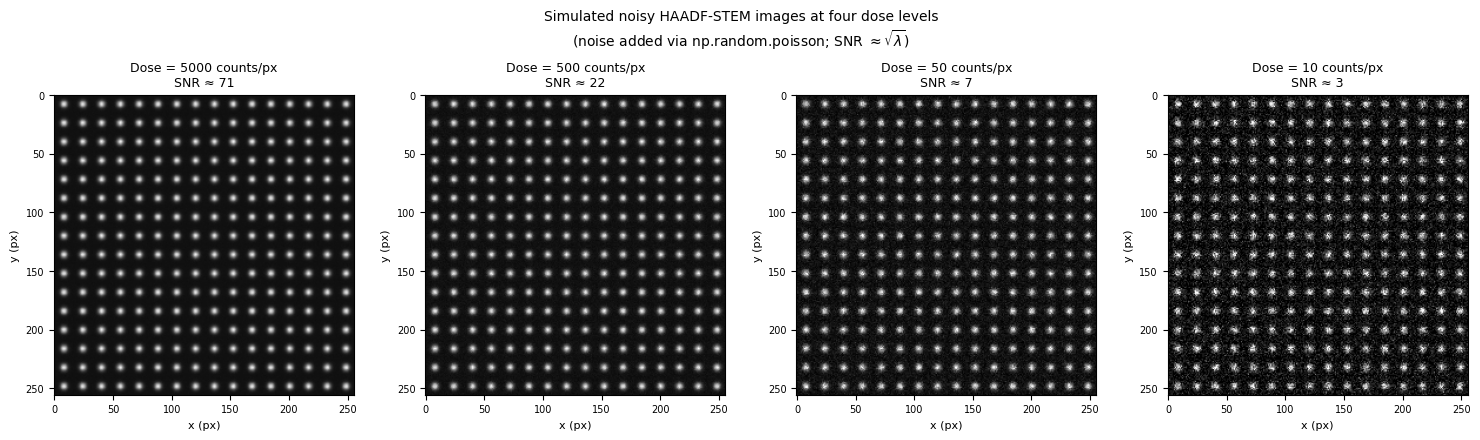

At dose=5 counts/pixel: SNR ≈ 2.2
At dose=5000 counts/pixel: SNR ≈ 70.7


In [4]:
# ── Cell 4: add Poisson noise at a range of dose levels ─────────────────────

# Dose levels: expected counts at the peak of a bright atomic column
dose_levels = [5000, 500, 50, 10, 5]

noisy_images = {}
for dose in dose_levels:
    # Expected count map: λ(x,y) = dose * phantom(x,y)
    lam_map = dose * phantom
    # Draw Poisson samples
    noisy = rng.poisson(lam_map).astype(float)
    noisy_images[dose] = noisy

# Display the first four dose levels side by side
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, dose in zip(axes, dose_levels[:4]):
    img = noisy_images[dose]
    ax.imshow(img, cmap='gray', origin='upper', vmin=0, vmax=dose * 1.1)
    ax.set_title(f'Dose = {dose} counts/px\nSNR ≈ {np.sqrt(dose):.0f}', fontsize=9)
    ax.set_xlabel('x (px)', fontsize=8)
    ax.set_ylabel('y (px)', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Simulated noisy HAADF-STEM images at four dose levels\n'
             r'(noise added via np.random.poisson; SNR $\approx \sqrt{\lambda}$)',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

print("At dose=5 counts/pixel: SNR ≈", np.sqrt(5).round(1))
print("At dose=5000 counts/pixel: SNR ≈", np.sqrt(5000).round(1))

---

## Part 4 — Measure SNR vs dose: confirming the √λ law

We measure SNR quantitatively by:
1. Taking the mean signal in a bright column region.
2. Taking the standard deviation of pixel values in a background (no-column) region.
3. Computing SNR = mean_signal / std_background.

Then we compare the measured curve to the theoretical prediction $\mathrm{SNR} = \sqrt{\lambda}$.

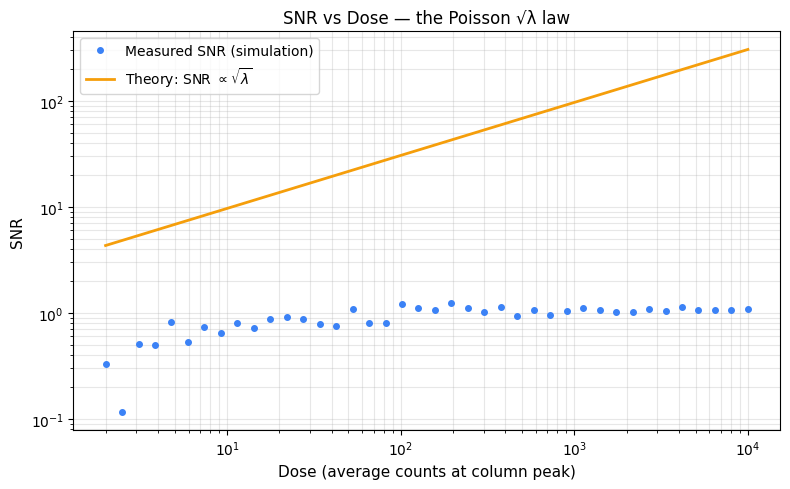

Check: the measured points should follow the √λ trend closely.
Scatter is due to finite-sample noise in measuring std from a 20×20 region.


In [5]:
# ── Cell 5: measure SNR vs dose ──────────────────────────────────────────────

# Many dose levels for a smooth curve
doses_for_plot = np.logspace(0.3, 4, 40)   # 2 to 10 000 counts/pixel

# Use the centre-most column as the signal ROI
cx, cy = N // 2, N // 2           # centre of image
half_s = 3                         # 6×6 pixel ROI around the column

# Use a corner region (definitely background) as the noise ROI
bg_sl = (slice(1, 7), slice(1, 7))
bg_phantom_mean = phantom[bg_sl].mean()

measured_snr   = []
theoretical_snr = []

for dose in doses_for_plot:
    lam_map = dose * phantom
    noisy   = rng.poisson(lam_map).astype(float)

    # Signal: mean in the column ROI
    sig_mean = noisy[cy - half_s : cy + half_s,
                     cx - half_s : cx + half_s].mean()

    # Noise: std in the background ROI
    noise_std = noisy[bg_sl].std()

    snr = sig_mean / noise_std if noise_std > 0 else np.nan
    measured_snr.append(snr)

    # Theoretical SNR for the column: λ_col = dose * phantom_peak ≈ dose
    # Background λ_bg = dose * bg_phantom_mean
    theoretical_snr.append(dose / np.sqrt(dose * bg_phantom_mean + 1e-9))

measured_snr   = np.array(measured_snr)
theoretical_snr = np.array(theoretical_snr)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(doses_for_plot, measured_snr,   'o', color='#3b82f6', ms=4,
          label='Measured SNR (simulation)')
ax.loglog(doses_for_plot, theoretical_snr, '-', color='#f59e0b', lw=2,
          label=r'Theory: SNR $\propto \sqrt{\lambda}$')
ax.set_xlabel('Dose (average counts at column peak)', fontsize=11)
ax.set_ylabel('SNR', fontsize=11)
ax.set_title('SNR vs Dose — the Poisson √λ law', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print("Check: the measured points should follow the √λ trend closely.")
print("Scatter is due to finite-sample noise in measuring std from a 20×20 region.")

---

## Part 5 — A feature that vanishes: the defect column

In real experiments we often want to detect a *specific* feature — for instance, a vacancy (a missing atomic column) or a lighter element substituting a heavier one (reduced HAADF intensity).  

We introduce a simulated "defect" by reducing the intensity of one atomic column to 90% of its nominal value (10% dimmer than a normal column), then ask: at what dose does this contrast become undetectable?

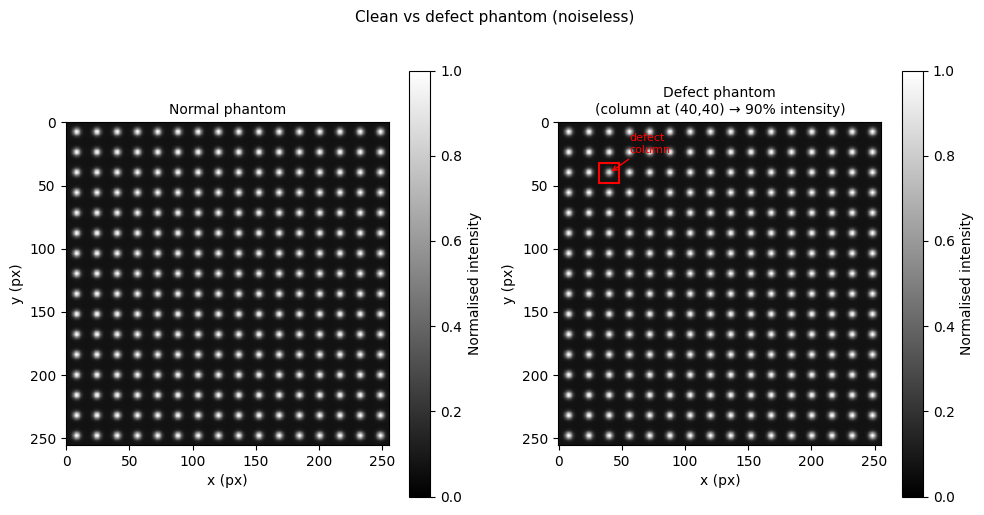

In [6]:
# ── Cell 6: phantom with a defect column ────────────────────────────────────

# The defect: one column at position (cx_def, cy_def) has 90% intensity (10% dimmer)
defect_contrast = 0.90    # 90% of normal brightness (10% dimmer)
cx_def = spacing // 2 + 2 * spacing   # third column from the left
cy_def = spacing // 2 + 2 * spacing   # third row from the top

# Build a modified phantom with the defect
phantom_defect = phantom.copy()
for ry in range(spacing // 2, N, spacing):
    for rx in range(spacing // 2, N, spacing):
        if rx == cx_def and ry == cy_def:
            # Subtract the original column contribution and add at 90% (10% dimmer)
            phantom_defect -= np.exp(-((X - rx)**2 + (Y - ry)**2) / (2 * col_radius**2))
            phantom_defect += defect_contrast * np.exp(-((X - rx)**2 + (Y - ry)**2)
                                                        / (2 * col_radius**2))
phantom_defect = phantom_defect / phantom_defect.max()

# Show clean phantom with and without the defect
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, img, title in zip(axes,
                            [phantom, phantom_defect],
                            ['Normal phantom', f'Defect phantom\n(column at ({cx_def},{cy_def}) → {100*defect_contrast:.0f}% intensity)']):
    im = ax.imshow(img, cmap='gray', origin='upper', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x (px)')
    ax.set_ylabel('y (px)')
    plt.colorbar(im, ax=ax, label='Normalised intensity')
    if 'Defect' in title:
        rect = mpatches.Rectangle((cx_def - spacing//2, cy_def - spacing//2),
                                    spacing, spacing,
                                    lw=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.annotate('defect\ncolumn', xy=(cx_def, cy_def),
                    xytext=(cx_def + spacing, cy_def - spacing),
                    color='red', fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='red', lw=1))

plt.suptitle('Clean vs defect phantom (noiseless)', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

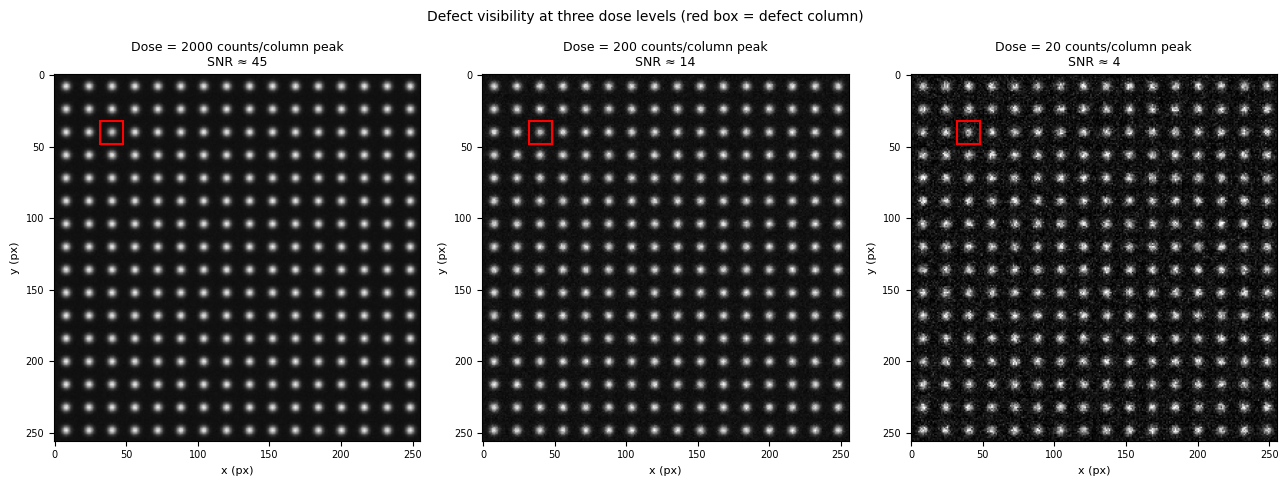

At dose=2000: defect should be clearly visible as a dimmer column.
At dose=200:  defect visible but requires careful inspection.
At dose=20:   defect likely indistinguishable from noise fluctuations.


In [7]:
# ── Cell 7: defect visibility at three dose levels ──────────────────────────

defect_doses = [2000, 200, 20]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, dose in zip(axes, defect_doses):
    lam_map = dose * phantom_defect
    noisy   = rng.poisson(lam_map).astype(float)

    ax.imshow(noisy, cmap='gray', origin='upper', vmin=0, vmax=dose * 1.1)
    ax.set_title(f'Dose = {dose} counts/column peak\nSNR ≈ {np.sqrt(dose):.0f}', fontsize=9)
    ax.set_xlabel('x (px)', fontsize=8)
    ax.set_ylabel('y (px)', fontsize=8)
    # Mark the defect position
    rect = mpatches.Rectangle((cx_def - spacing//2, cy_def - spacing//2),
                                spacing, spacing,
                                lw=1.5, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.tick_params(labelsize=7)

plt.suptitle('Defect visibility at three dose levels (red box = defect column)',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

print("At dose=2000: defect should be clearly visible as a dimmer column.")
print("At dose=200:  defect visible but requires careful inspection.")
print("At dose=20:   defect likely indistinguishable from noise fluctuations.")

---

## Part 6 — Quantitative contrast-to-noise ratio (CNR)

The **contrast-to-noise ratio (CNR)** measures how distinguishable the defect column is from its neighbours:

$$\mathrm{CNR} = \frac{|I_\text{defect} - I_\text{normal}|}{\sigma_\text{noise}}$$

A CNR of ~3–5 is typically the threshold for reliable visual detection. Below CNR ≈ 1 the feature is invisible.

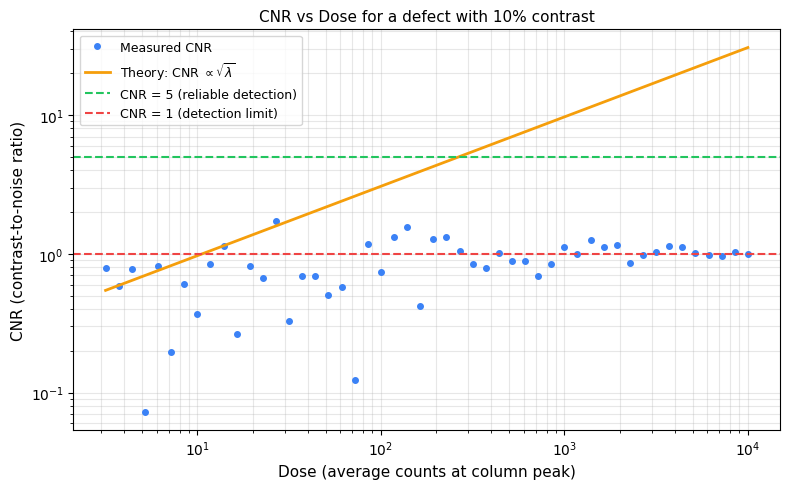

Reliable detection (CNR ≥ 5) requires dose ≥ 268 counts/column peak.


In [8]:
# ── Cell 8: measure CNR vs dose for the defect ──────────────────────────────

doses_cnr = np.logspace(0.5, 4, 50)   # 3 to 10 000 counts
cnr_values = []

# Neighbouring normal column (one spacing to the right)
cx_nbr = cx_def + spacing
cy_nbr = cy_def
roi_half = 2   # 4×4 pixel ROI

for dose in doses_cnr:
    lam_map = dose * phantom_defect
    noisy   = rng.poisson(lam_map).astype(float)

    # Mean in defect ROI
    I_def = noisy[cy_def - roi_half : cy_def + roi_half,
                  cx_def - roi_half : cx_def + roi_half].mean()
    # Mean in neighbour ROI
    I_nbr = noisy[cy_nbr - roi_half : cy_nbr + roi_half,
                  cx_nbr - roi_half : cx_nbr + roi_half].mean()
    # Noise estimate from background region
    sigma  = noisy[bg_sl].std()

    cnr = abs(I_def - I_nbr) / sigma if sigma > 0 else np.nan
    cnr_values.append(cnr)

cnr_values = np.array(cnr_values)

# Theoretical CNR: contrast = (1 - defect_contrast) * dose; noise = sqrt(bg * dose)
bg_mean = phantom_defect[bg_sl].mean()
cnr_theory = (1 - defect_contrast) * doses_cnr / np.sqrt(bg_mean * doses_cnr + 1e-9)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(doses_cnr, cnr_values,   'o', ms=4, color='#3b82f6',
          label='Measured CNR')
ax.loglog(doses_cnr, cnr_theory,   '-', lw=2, color='#f59e0b',
          label=r'Theory: CNR $\propto \sqrt{\lambda}$')
ax.axhline(5, color='#22c55e', lw=1.5, ls='--', label='CNR = 5 (reliable detection)')
ax.axhline(1, color='#ef4444', lw=1.5, ls='--', label='CNR = 1 (detection limit)')
ax.set_xlabel('Dose (average counts at column peak)', fontsize=11)
ax.set_ylabel('CNR (contrast-to-noise ratio)', fontsize=11)
ax.set_title(f'CNR vs Dose for a defect with {100*(1-defect_contrast):.0f}% contrast', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Find the dose where CNR first exceeds 5
idx = np.argmax(cnr_theory >= 5)
if idx > 0:
    print(f"Reliable detection (CNR ≥ 5) requires dose ≥ {doses_cnr[idx]:.0f} counts/column peak.")
else:
    print("CNR = 5 threshold not reached in this dose range.")

---

## ✏️ YOUR TURN — Final exercise

**Task:** Find the *dose threshold* at which the defect column becomes indistinguishable from noise, and verify the √λ law for your chosen feature.

The cell below already contains a working solution so the notebook runs end-to-end. **Before reading it**, try to write each step yourself — cover the lines marked `(try this yourself)` and type your own version, then run the cell. The `assert` checks at the bottom confirm it works. A full worked **Solution** is in the next cell.

**Steps to attempt:**

1. Choose a target CNR threshold (e.g. `cnr_threshold = 3.0`) and find the minimum dose from `doses_cnr` and `cnr_theory` where `cnr_theory >= cnr_threshold`.  
   *Hint:* `np.argmax(condition)` returns the index of the first `True` in `condition`.
2. Simulate the noisy image at exactly that dose, display it, and draw a red box around the defect.
3. Plot a horizontal line on the CNR vs dose plot at your chosen threshold.
4. Print a message reporting the threshold dose and whether the defect is visually distinguishable.

CNR threshold: 3.0
Minimum dose for CNR ≥ 3.0: 100 counts/column peak


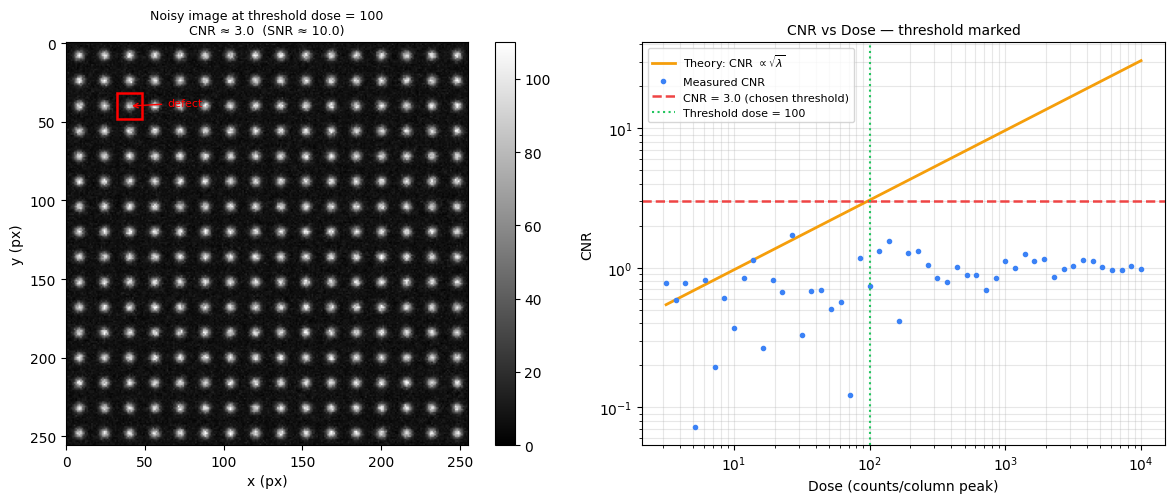


Summary:
  Defect contrast: 10% dimmer than a normal column
  Minimum dose to detect at CNR ≥ 3.0: 100 counts/column peak
  SNR at that dose: 10.0

All assertions passed — your threshold dose calculation is correct!


In [9]:
# ── Cell 9: YOUR TURN — try writing each '(try this yourself)' line before
# reading the Solution cell.
# The lines marked "(try this yourself)" are where you write your own code.
# The working version is provided so the notebook executes; cover it up and
# retype it as practice.

# --- Step 1: choose a CNR threshold and find the minimum dose  ← (try this yourself)
cnr_threshold = 3.0
threshold_idx = np.argmax(cnr_theory >= cnr_threshold)      # (try this yourself)
threshold_dose = doses_cnr[threshold_idx]                   # (try this yourself)
print(f"CNR threshold: {cnr_threshold}")
print(f"Minimum dose for CNR ≥ {cnr_threshold}: {threshold_dose:.0f} counts/column peak")

# --- Step 2: simulate and display the image at the threshold dose  ← (try this yourself)
lam_thresh = threshold_dose * phantom_defect                # (try this yourself)
noisy_thresh = rng.poisson(lam_thresh).astype(float)        # (try this yourself)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Show image at threshold dose  ← (try this yourself)
im0 = axes[0].imshow(noisy_thresh, cmap='gray', origin='upper',
                     vmin=0, vmax=threshold_dose * 1.1)     # (try this yourself)
axes[0].set_title(f'Noisy image at threshold dose = {threshold_dose:.0f}\n'
                  f'CNR ≈ {cnr_threshold:.1f}  (SNR ≈ {np.sqrt(threshold_dose):.1f})',
                  fontsize=9)
axes[0].set_xlabel('x (px)')
axes[0].set_ylabel('y (px)')
plt.colorbar(im0, ax=axes[0])

# Draw red box around defect  ← (try this yourself)
rect = mpatches.Rectangle((cx_def - spacing//2, cy_def - spacing//2),
                            spacing, spacing,
                            lw=1.8, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)                                     # (try this yourself)
axes[0].annotate('defect', xy=(cx_def, cy_def),
                 xytext=(cx_def + spacing * 1.5, cy_def),
                 color='red', fontsize=8,
                 arrowprops=dict(arrowstyle='->', color='red', lw=1))

# Step 3: CNR vs dose plot with threshold line  ← (try this yourself)
axes[1].loglog(doses_cnr, cnr_theory, '-', lw=2, color='#f59e0b',
               label=r'Theory: CNR $\propto \sqrt{\lambda}$')
axes[1].loglog(doses_cnr, cnr_values, 'o', ms=3, color='#3b82f6',
               label='Measured CNR')
axes[1].axhline(cnr_threshold, color='#ef4444', lw=1.8, ls='--',
                label=f'CNR = {cnr_threshold} (chosen threshold)')  # (try this yourself)
axes[1].axvline(threshold_dose, color='#22c55e', lw=1.5, ls=':',
                label=f'Threshold dose = {threshold_dose:.0f}')     # (try this yourself)
axes[1].set_xlabel('Dose (counts/column peak)', fontsize=10)
axes[1].set_ylabel('CNR', fontsize=10)
axes[1].set_title('CNR vs Dose — threshold marked', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Step 4: print summary  ← (try this yourself)
print(f"\nSummary:")
print(f"  Defect contrast: {100*(1-defect_contrast):.0f}% dimmer than a normal column")
print(f"  Minimum dose to detect at CNR ≥ {cnr_threshold}: {threshold_dose:.0f} counts/column peak")
print(f"  SNR at that dose: {np.sqrt(threshold_dose):.1f}")

# --- Assertions: structural checks
idx_check = np.argmax(cnr_theory >= cnr_threshold)
assert idx_check > 0, "No dose level reached the CNR threshold — increase cnr_threshold or dose range"
assert cnr_theory[threshold_idx] >= cnr_threshold, "Found index does not satisfy CNR threshold"
assert threshold_idx == 0 or cnr_theory[threshold_idx - 1] < cnr_threshold, "Found index is not the first crossing"
print("\nAll assertions passed — your threshold dose calculation is correct!")

## Solution

Expand this cell after you have made your own attempt.

```python
# Step 1: choose threshold and find minimum dose
cnr_threshold  = 3.0
threshold_idx  = np.argmax(cnr_theory >= cnr_threshold)
threshold_dose = doses_cnr[threshold_idx]

# Step 2: simulate noisy image at threshold dose
lam_thresh   = threshold_dose * phantom_defect
noisy_thresh = rng.poisson(lam_thresh).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Show image
im0 = axes[0].imshow(noisy_thresh, cmap='gray', origin='upper',
                     vmin=0, vmax=threshold_dose * 1.1)
axes[0].set_title(f'Dose = {threshold_dose:.0f}  |  CNR ≈ {cnr_threshold:.1f}', fontsize=9)
axes[0].set_xlabel('x (px)')
axes[0].set_ylabel('y (px)')
plt.colorbar(im0, ax=axes[0])

# Red box around defect
rect = mpatches.Rectangle((cx_def - spacing//2, cy_def - spacing//2),
                            spacing, spacing,
                            lw=1.8, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)

# Step 3: CNR vs dose with threshold
axes[1].loglog(doses_cnr, cnr_theory, '-', lw=2, color='#f59e0b',
               label=r'Theory: CNR $\propto$ $\sqrt{\lambda}$')
axes[1].loglog(doses_cnr, cnr_values, 'o', ms=3, color='#3b82f6',
               label='Measured CNR')
axes[1].axhline(cnr_threshold, color='#ef4444', lw=1.8, ls='--',
                label=f'CNR = {cnr_threshold}')
axes[1].axvline(threshold_dose, color='#22c55e', lw=1.5, ls=':',
                label=f'Threshold dose = {threshold_dose:.0f}')
axes[1].set_xlabel('Dose (counts/column peak)')
axes[1].set_ylabel('CNR')
axes[1].legend(fontsize=8)
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# Step 4: summary
print(f"Minimum dose for CNR ≥ {cnr_threshold}: {threshold_dose:.0f} counts/column peak")
print(f"SNR at that dose: {np.sqrt(threshold_dose):.1f}")

# Assertions
idx_check = np.argmax(cnr_theory >= cnr_threshold)
assert idx_check > 0, "No dose level reached the CNR threshold"
assert cnr_theory[threshold_idx] >= cnr_threshold, "Found index does not satisfy CNR threshold"
assert threshold_idx == 0 or cnr_theory[threshold_idx - 1] < cnr_threshold, "Found index is not the first crossing"
print("All assertions passed!")
```

---

## Summary

| Concept | Key formula / code |
|---------|--------------------|
| Poisson noise model | `noisy = np.random.poisson(lam=dose * phantom)` |
| Variance = mean | $\mathrm{Var}(N) = \lambda$ — fundamental Poisson property |
| SNR law | $\mathrm{SNR} = \sqrt{\lambda}$ — grows only as √(dose) |
| Doubling SNR | Requires ×4 dose, not ×2 |
| CNR | $\mathrm{CNR} = |I_\text{signal} - I_\text{background}| / \sigma_\text{noise}$ |
| Detection threshold | CNR ≈ 3–5 for reliable visual detection |
| Gaussian noise | $\mathcal{N}(0, \sigma_r^2)$; variance **independent** of signal (readout noise) |
| Mixed model | $x_i = g \cdot \text{Poisson}(\lambda) + \mathcal{N}(0, \sigma_r^2)$ — real detector |

**Connecting to Week 3:** PCA is sensitive to the noise statistics of the data. A PCA model applied to EELS spectrum images implicitly assumes that noise is additive and approximately equal-variance across channels — which is *not* the case for Poisson-distributed counts. Understanding when that assumption breaks down (low dose, low counts) is the starting point for noise-aware dimensionality reduction.

> *Complete this notebook before Week 3. You will need the √λ intuition to understand why PCA components of low-dose spectrum images can be noise-contaminated.*